In [2]:
#1. IMPORTS
#==========================
import pandas as pd
import numpy as np

from scipy.stats import zscore
# Add project root to sys.path
import os
sys.path.insert(0, os.path.abspath("..")) 
    
from src.data.loader import load_dataset
from src.visualization.eda_plots import (
    plot_target_distribution,
    plot_feature_distributions,
    plot_correlation_matrix,
    plot_feature_vs_target
)

In [4]:
#1. Dataset loading and peeking
#==========================
df = load_dataset()

print(df.shape)

df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
#3. Dataset overview
#==========================
df.info()
df.describe().T


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


In [6]:
#4. Missing Value Analysis
#==========================
missing_values = df.isnull().sum()

missing_values

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [7]:
missing_report = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage":
        df.isnull().mean() * 100
})

missing_report

,missing_count,missing_percentage
MedInc,0,0.0
HouseAge,0,0.0
AveRooms,0,0.0
AveBedrms,0,0.0
Population,0,0.0
AveOccup,0,0.0
Latitude,0,0.0
Longitude,0,0.0
MedHouseVal,0,0.0


In [9]:
#5. Duplicate Analysis
#==========================
duplicates = df.duplicated().sum()

print(
    f"Duplicate rows: {duplicates}"
)

Duplicate rows: 0


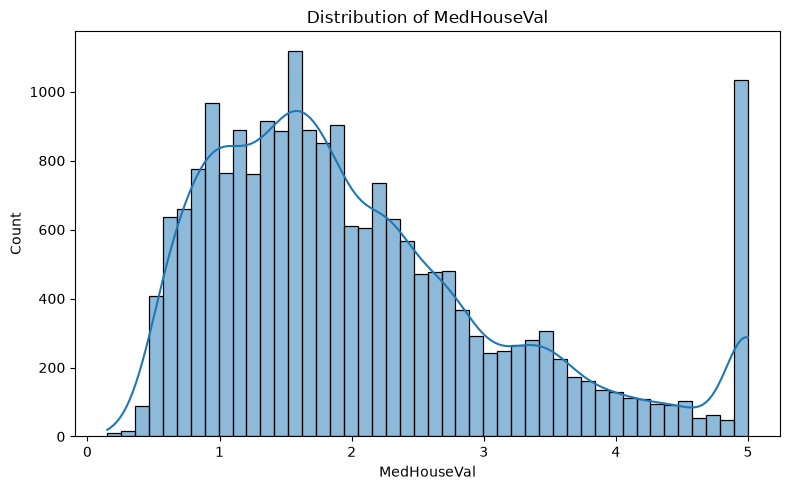

In [10]:
#6. Target Distribution
#==========================
plot_target_distribution(
    df,
    "MedHouseVal"
)

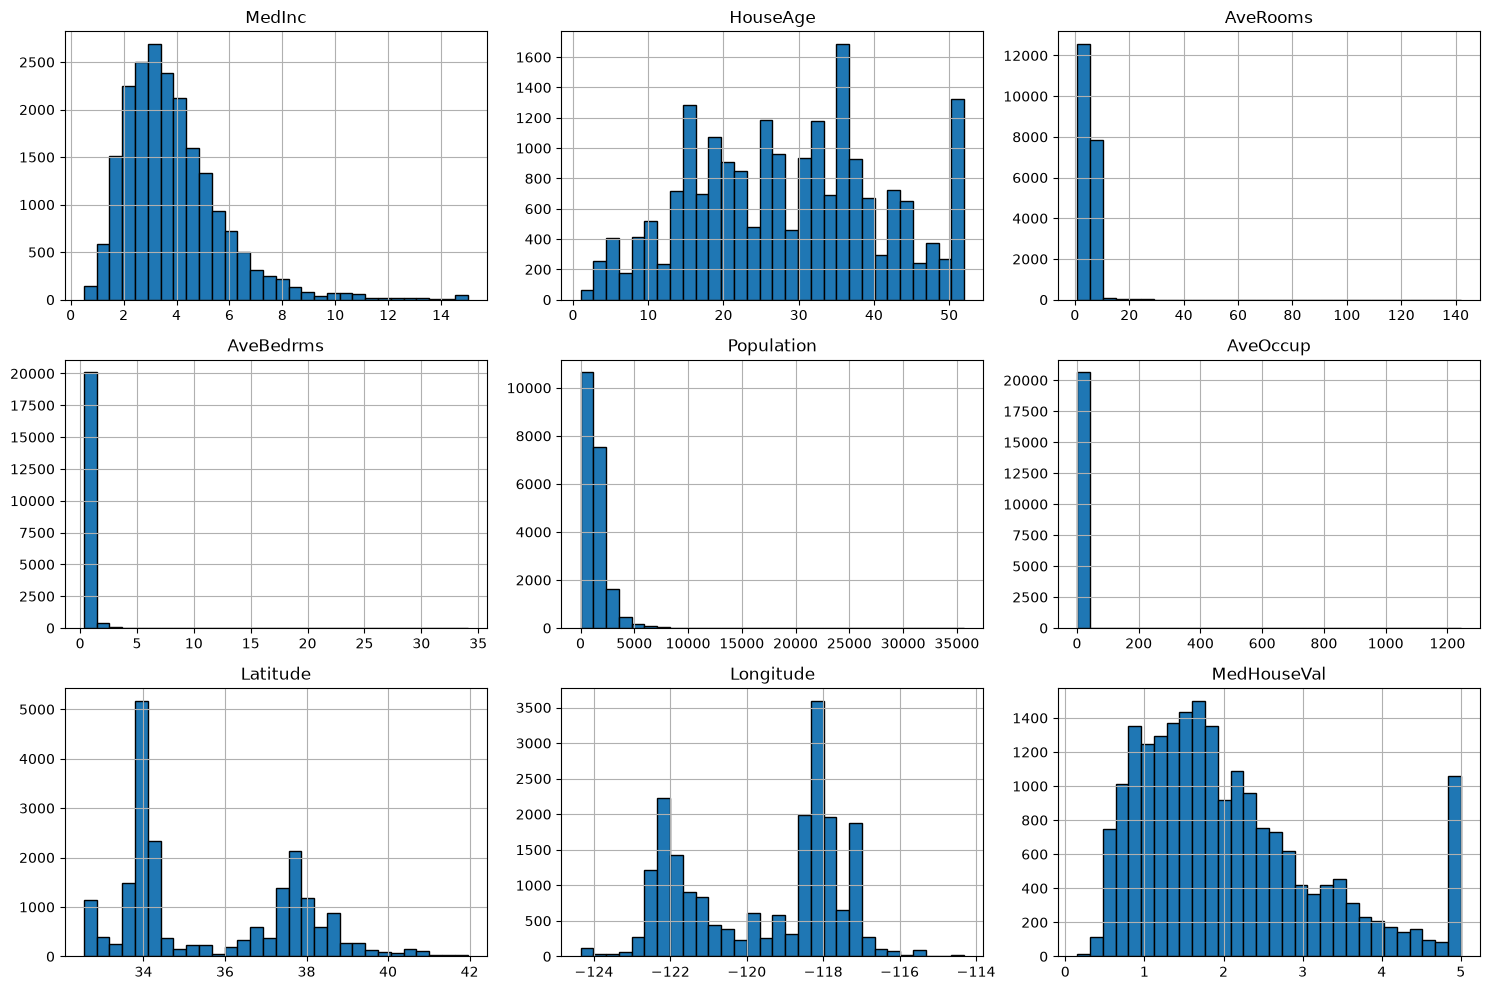

In [11]:
#7. Feature Distribution
#==========================
plot_feature_distributions(df)

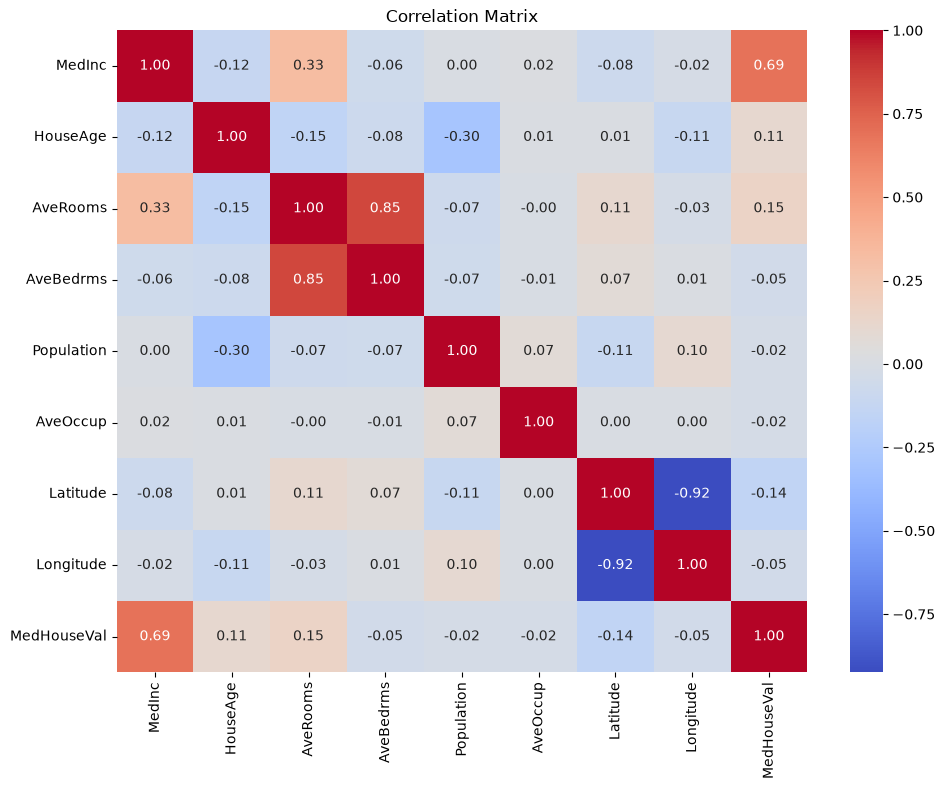

In [12]:
#8. Correlation Analysis
#==========================
plot_correlation_matrix(df)


In [13]:
corr_target = (
    df.corr()["MedHouseVal"]
    .sort_values(
        ascending=False
    )
)

corr_target

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

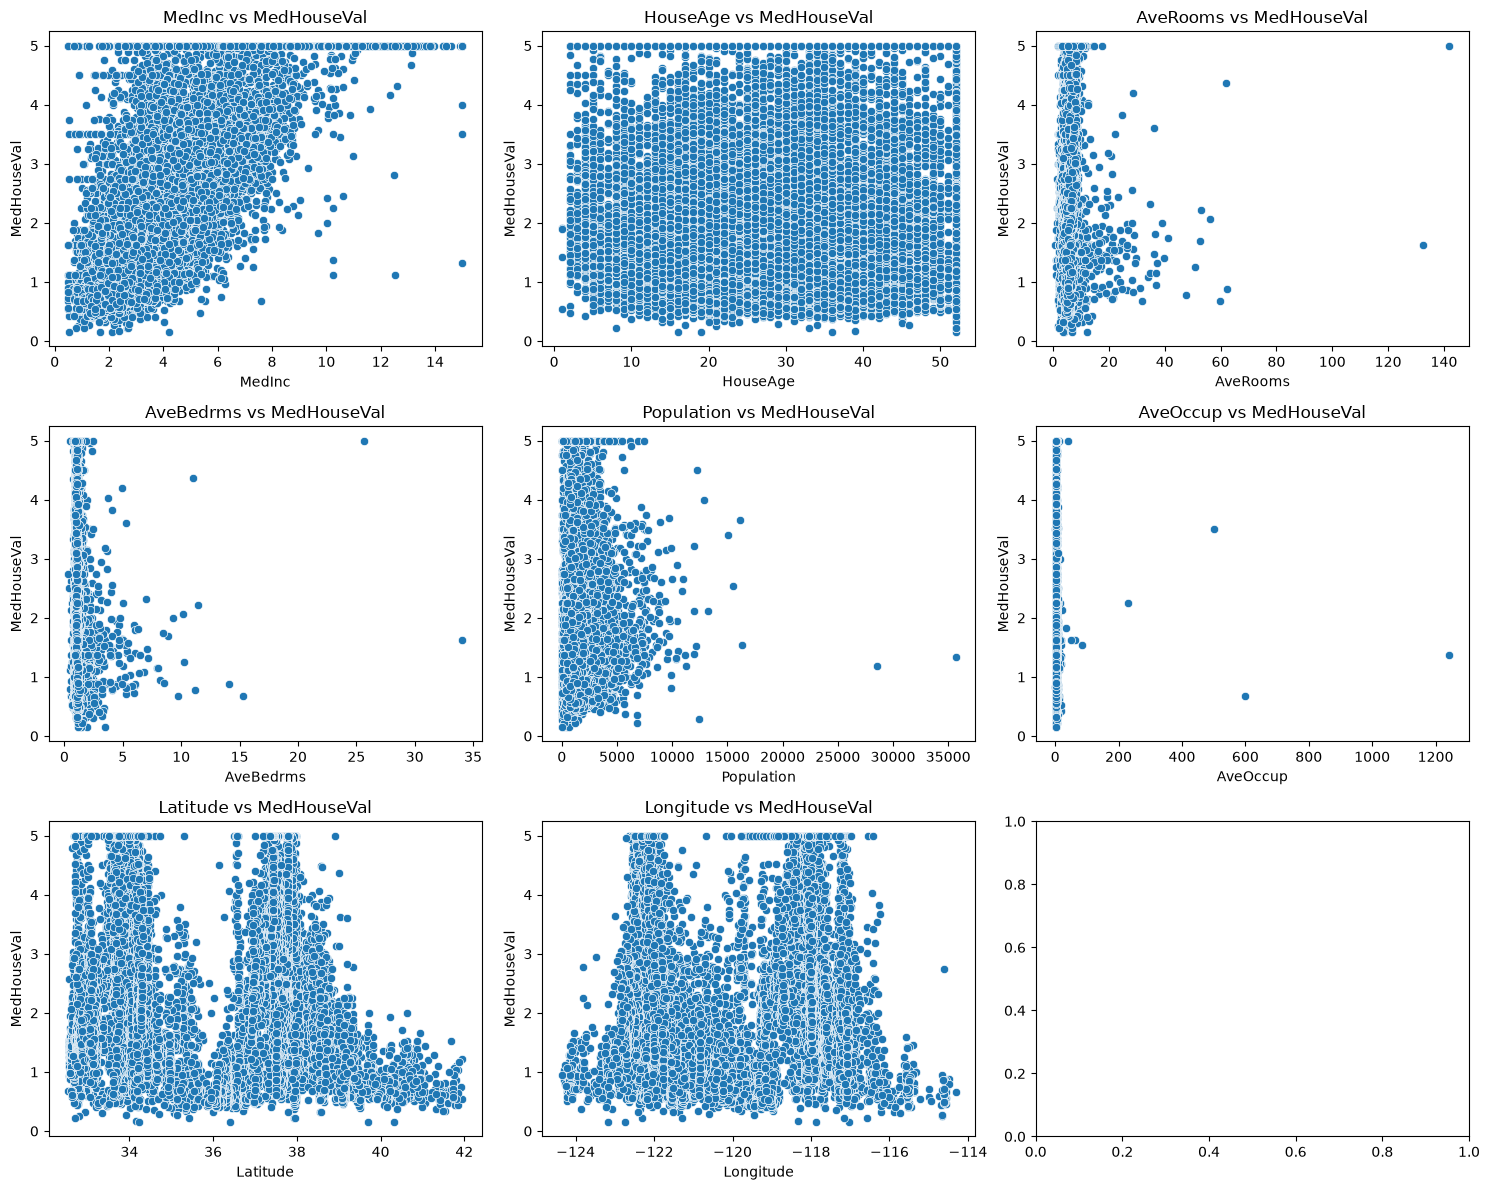

In [14]:
#9. Feature-Target Relationships
#==========================
plot_feature_vs_target(
    df,
    "MedHouseVal"
)

In [15]:
#10. Outlier Analysis
#==========================
#Z-score method
numerical_cols = df.columns

z_scores = np.abs(
    zscore(
        df[numerical_cols]
    )
)

outliers = (
    z_scores > 3
).sum(axis=0)

pd.Series(
    outliers,
    index=numerical_cols
)

MedInc         345
HouseAge         0
AveRooms       133
AveBedrms      145
Population     342
AveOccup         8
Latitude         0
Longitude        0
MedHouseVal      0
dtype: int64

In [16]:
#11. Top Extreme Occupancy Values
#==========================
df.sort_values(
    "AveOccup",
    ascending=False
).head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
19006,10.2264,45.0,3.166667,0.833333,7460.0,1243.333333,38.32,-121.98,1.37500
3364,5.5179,36.0,5.142857,1.142857,4198.0,599.714286,40.41,-120.51,0.67500
16669,4.2639,46.0,9.076923,1.307692,6532.0,502.461538,35.32,-120.70,3.50000
13034,6.1359,52.0,8.275862,1.517241,6675.0,230.172414,38.69,-121.15,2.25000
9172,4.2391,5.0,5.123810,0.933333,8733.0,83.171429,34.47,-118.59,1.54600
12104,1.6250,8.0,7.600000,0.950000,1275.0,63.750000,33.97,-117.33,1.62500
16420,5.7485,26.0,5.366667,0.900000,1542.0,51.400000,37.89,-121.29,1.62500
8874,9.3370,52.0,7.285714,1.214286,1154.0,41.214286,34.06,-118.45,5.00001
13366,4.2578,36.0,5.258824,1.117647,2886.0,33.952941,33.94,-117.63,1.83300
5986,1.8750,52.0,4.500000,1.206349,2688.0,21.333333,34.10,-117.71,2.12500
